# 10｜TinyViT Attention Map 可视化

上一课通过局部扰动看到：一个 patch 的变化经过第一个 Encoder Block 后，可以传播到全部 65 个 token。本课进一步打开 Self-Attention，观察训练好的 TinyViT 中，**CLS token 正在关注哪些 patch**。

本课直接加载已经训练完成的最佳 checkpoint，不重新训练，也不修改模型文件。

## 1. 本课目标

完成后应能：

1. 解释注意力矩阵 `B x H x N x N` 四个维度；
2. 从矩阵中正确取出 `CLS query → patch keys`；
3. 把 64 个权重还原成 `8 x 8` patch 网格；
4. 对比第一层与最后一层 Attention Map；
5. 观察不同注意力头是否关注不同区域；
6. 理解 Attention Map 的解释边界。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import torch.nn.functional as F
from IPython.display import display
from torchvision import datasets, transforms

from vit import BEST_MODEL_PATH, DATA_ROOT, TinyViT
from vit.data import CIFAR10_MEAN, CIFAR10_STD

# 注册 Jupyter inline 后端，使执行后的图片直接嵌入 notebook。
get_ipython().run_line_magic("matplotlib", "inline")
mpl.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
mpl.rcParams["axes.unicode_minus"] = False
# 本课只推理 4 张小图，固定使用 CPU 可避免不同机器的 CUDA/cuDNN 版本差异。
device = torch.device("cpu")
print("计算设备：", device)

计算设备： cpu


## 2. 注意力矩阵的 shape

当前模型有 4 个注意力头、65 个 token，因此每层权重为：

$$B \times H \times N \times N = B \times 4 \times 65 \times 65$$

最后两个维度不能混淆：

- 倒数第二维是 **Query 位置**：谁正在寻找信息；
- 最后一维是 **Key 位置**：它把注意力分给了谁。

CLS 位于第 0 个位置，因此：

```python
attention[:, :, 0, 1:]
```

表示所有注意力头中，CLS query 分配给 64 个 patch keys 的权重。排除最后一维的第 0 项，是因为那一项代表 CLS 对自身的注意力。

## 3. 加载训练好的 TinyViT

checkpoint 保存了模型权重和训练状态。这里只读取 `model_state_dict`，并切换到 `eval()`：关闭 Dropout，使同一张图片每次得到稳定的注意力结果。

In [2]:
checkpoint_path = Path(BEST_MODEL_PATH)
if not checkpoint_path.exists():
    raise FileNotFoundError(f"没有找到 checkpoint：{checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
model = TinyViT().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("checkpoint：", checkpoint_path)
print("保存 epoch：", checkpoint["epoch"])
print(f"验证准确率：{checkpoint['validation_accuracy'] * 100:.2f}%")
print("Encoder Blocks：", model.encoder.num_blocks)
print("注意力头数：", model.encoder.blocks[0].attention_sub_layer.multi_head_attention.num_heads)

checkpoint： D:\PythonWorkSpace\files\Deep Learning\vision_transformer_practice\checkpoints\tiny_vit_best.pt
保存 epoch： 278
验证准确率：89.74%
Encoder Blocks： 6
注意力头数： 4


## 4. 在不修改模型文件的情况下提取权重

训练时模型调用 MHA 使用 `need_weights=False`，这样能减少额外计算和内存。现在为了可视化，我们在 notebook 中按原顺序重放每个 Block：

```text
LN1 → MHA(返回权重) → Dropout → 残差相加 → MLP 子层
```

`average_attn_weights=False` 非常重要。若为 True，PyTorch 会提前平均多个 head，我们就无法继续观察各个 head 的差异。

In [3]:
def forward_with_attention(model, images):
    """返回 logits 和全部层注意力；attention shape 为 BxLxHxNxN。"""
    x = model.input_embedding(images)
    attention_per_layer = []

    for block in model.encoder.blocks:
        attention_layer = block.attention_sub_layer
        residual = x
        normalized = attention_layer.layer_norm1(x)
        attention_output, attention_weights = attention_layer.multi_head_attention(
            query=normalized,
            key=normalized,
            value=normalized,
            need_weights=True,
            average_attn_weights=False,
        )
        x = residual + attention_layer.dropout(attention_output)
        x = block.mlp_sub_layer(x)
        attention_per_layer.append(attention_weights)

    x = model.encoder.final_layer_norm(x)
    logits = model.classification_head(x[:, 0])
    attention = torch.stack(attention_per_layer, dim=1)
    return logits, attention

test_input = torch.randn(2, 3, 32, 32, device=device)
with torch.inference_mode():
    normal_logits = model(test_input)
    replay_logits, test_attention = forward_with_attention(model, test_input)

print("logits shape：", tuple(replay_logits.shape))
print("attention shape：", tuple(test_attention.shape))
print("两种 forward 最大差值：", (normal_logits - replay_logits).abs().max().item())
print("每行注意力权重和：", test_attention[0, 0, 0, 0].sum().item())

assert test_attention.shape == (2, 6, 4, 65, 65)
assert torch.allclose(normal_logits, replay_logits, atol=1e-5, rtol=1e-5)
assert torch.allclose(test_attention.sum(dim=-1), torch.ones_like(test_attention.sum(dim=-1)), atol=1e-5)

logits shape： (2, 10)
attention shape： (2, 6, 4, 65, 65)
两种 forward 最大差值： 0.0
每行注意力权重和： 1.0


## 5. 读取测试图片并完成预测

测试集只使用 `ToTensor + Normalize`，不加入随机增强。展示图片时再执行反标准化，使颜色回到接近原图的范围。

In [4]:
evaluation_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
test_dataset = datasets.CIFAR10(
    root=DATA_ROOT, train=False, transform=evaluation_transform, download=False
)
sample_indices = [0, 1, 2, 3]
samples = [test_dataset[index] for index in sample_indices]
images = torch.stack([sample[0] for sample in samples]).to(device)
labels = torch.tensor([sample[1] for sample in samples], device=device)

with torch.inference_mode():
    logits, attention = forward_with_attention(model, images)
predictions = logits.argmax(dim=1)

mean = torch.tensor(CIFAR10_MEAN, device=device).view(1, 3, 1, 1)
std = torch.tensor(CIFAR10_STD, device=device).view(1, 3, 1, 1)
display_images = (images * std + mean).clamp(0, 1).cpu()

for index, true_label, predicted_label in zip(sample_indices, labels, predictions):
    print(
        f"index={index:2d} 真实={test_dataset.classes[true_label.item()]:10s} "
        f"预测={test_dataset.classes[predicted_label.item()]:10s} "
        f"正确={bool(true_label == predicted_label)}"
    )

index= 0 真实=cat        预测=cat        正确=True
index= 1 真实=ship       预测=ship       正确=True
index= 2 真实=ship       预测=ship       正确=True
index= 3 真实=airplane   预测=airplane   正确=True


## 6. 从 64 个权重还原热力图

处理步骤：

1. 取 CLS query，即 Query 维第 0 行；
2. 去掉 CLS key，只保留后面 64 个 patch；
3. 对 4 个 head 求平均；
4. 从长度 64 reshape 为 `8 x 8`；
5. 双线性插值到 `32 x 32`，便于和原图叠加；
6. 每张图单独归一化到 0～1，便于观察相对强弱。

这里的归一化只服务于显示，不会参与模型预测。

### 单张热力图应该怎么看？

把热力图和原图叠加后，颜色表示的是 **CLS token 当前更重视哪些 patch**，不是像素级的物体轮廓：

- 亮色区域：CLS 对这些 patch 分配的注意力权重相对较大；
- 暗色区域：当前这一层、这一组 head 分配的权重相对较小，但不等于这些区域完全没有作用；
- 亮点覆盖目标主体：说明注意力分布与人的直觉较一致，是一个积极线索；
- 亮点落在背景、边缘或固定位置：要警惕模型学到了背景捷径，而不是类别本身；
- 亮点分散在多个位置：可能表示模型在整合全局上下文，也可能表示当前层还没有形成清晰的目标定位。

读图时先问三件事：真实类别和预测类别是什么？亮区是否覆盖目标？换一张同类图片后，这种模式是否仍然出现？单张图的漂亮热力图不能单独证明模型具有良好的可解释性。

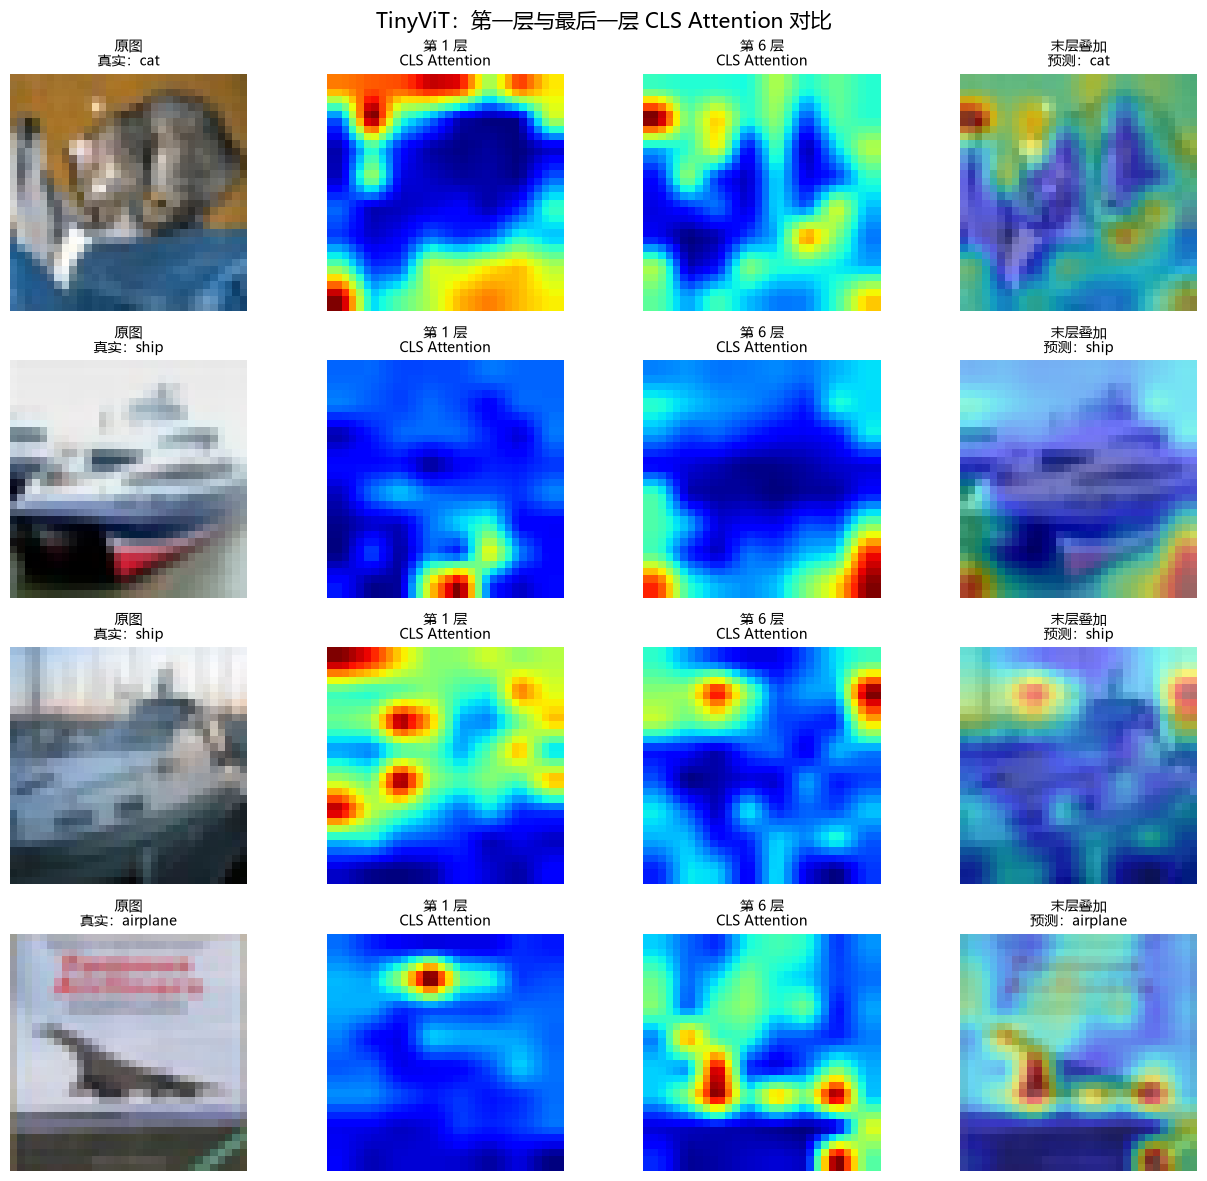

In [5]:
def cls_attention_map(attention, layer_index):
    """取指定层 CLS→patch 权重，返回归一化后的 Bx32x32 热力图。"""
    cls_to_patches = attention[:, layer_index, :, 0, 1:].mean(dim=1)
    maps = cls_to_patches.reshape(-1, 1, 8, 8)
    maps = F.interpolate(maps, size=(32, 32), mode="bilinear", align_corners=False)[:, 0]
    minimum = maps.flatten(1).min(dim=1).values[:, None, None]
    maximum = maps.flatten(1).max(dim=1).values[:, None, None]
    return (maps - minimum) / (maximum - minimum + 1e-8)

first_maps = cls_attention_map(attention, layer_index=0).cpu()
last_maps = cls_attention_map(attention, layer_index=-1).cpu()

fig, axes = plt.subplots(len(sample_indices), 4, figsize=(13, 12))
for row in range(len(sample_indices)):
    image = display_images[row].permute(1, 2, 0)
    titles = [
        f"原图\n真实：{test_dataset.classes[labels[row].item()]}",
        "第 1 层\nCLS Attention",
        "第 6 层\nCLS Attention",
        f"末层叠加\n预测：{test_dataset.classes[predictions[row].item()]}",
    ]
    axes[row, 0].imshow(image)
    axes[row, 1].imshow(first_maps[row], cmap="jet", vmin=0, vmax=1)
    axes[row, 2].imshow(last_maps[row], cmap="jet", vmin=0, vmax=1)
    axes[row, 3].imshow(image)
    axes[row, 3].imshow(last_maps[row], cmap="jet", alpha=0.5, vmin=0, vmax=1)
    for column, title in enumerate(titles):
        axes[row, column].set_title(title, fontsize=10)
        axes[row, column].axis("off")

plt.suptitle("TinyViT：第一层与最后一层 CLS Attention 对比", fontsize=15)
plt.tight_layout()
display(fig)
plt.close(fig)

## 7. 四个注意力头是否关注同一区域

多头注意力不是把同一件事机械重复四次。每个 head 拥有自己的 Q、K、V 投影参数，可能学习到不同关系。下面只看第 1 张图片的最后一层，并分别展示 4 个 head。

不要强行给每个 head 命名为“轮廓头”或“背景头”。单张图片只能提供观察线索，若想形成可靠结论，需要统计大量样本。

### 不同层的热力图怎么比较？

通常可以把浅层理解为更接近局部纹理、边缘和邻近 patch 的关系，把深层理解为更接近类别相关的全局信息；但这只是常见趋势，不是硬性规律。实际比较时：

1. 对同一张图片比较不同层，观察关注区域是否从局部、分散的纹理逐渐聚合到目标主体；
2. 检查深层亮区是否稳定落在目标上，而不是只落在背景或图像边缘；
3. 不要要求所有层都只关注主体，分类模型有时确实需要背景、姿态或物体之间的关系；
4. 比较时尽量使用相同的颜色范围，否则不同图各自归一化后，颜色深浅不能直接进行绝对比较。

因此，层间热力图主要回答“信息聚合模式如何变化”，而不是简单判断“哪一层最好”。

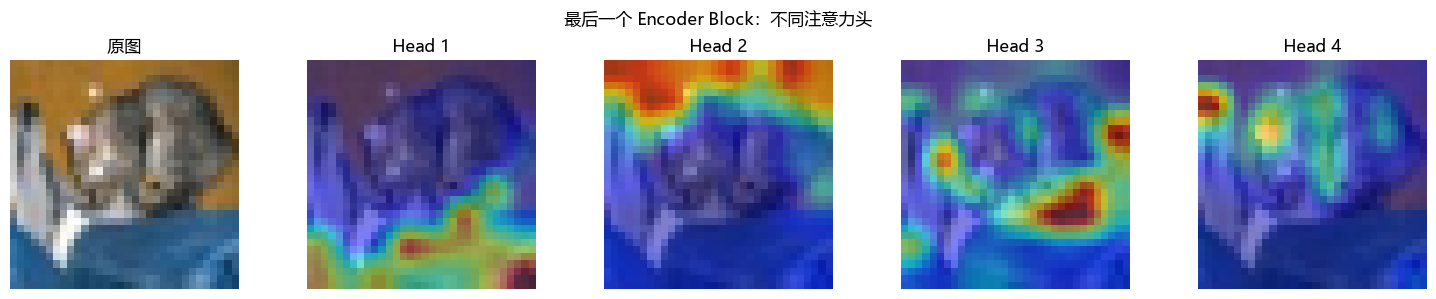

In [6]:
sample_attention = attention[0, -1, :, 0, 1:].reshape(4, 1, 8, 8)
head_maps = F.interpolate(
    sample_attention, size=(32, 32), mode="bilinear", align_corners=False
)[:, 0].cpu()
head_min = head_maps.flatten(1).min(dim=1).values[:, None, None]
head_max = head_maps.flatten(1).max(dim=1).values[:, None, None]
head_maps = (head_maps - head_min) / (head_max - head_min + 1e-8)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
image = display_images[0].permute(1, 2, 0)
axes[0].imshow(image)
axes[0].set_title("原图")
for head_index in range(4):
    axes[head_index + 1].imshow(image)
    axes[head_index + 1].imshow(head_maps[head_index], cmap="jet", alpha=0.5)
    axes[head_index + 1].set_title(f"Head {head_index + 1}")
for axis in axes:
    axis.axis("off")
plt.suptitle("最后一个 Encoder Block：不同注意力头")
plt.tight_layout()
display(fig)
plt.close(fig)

## 8. 用注意力熵观察集中程度

热力图适合直观观察，熵可以把“分散还是集中”压缩成一个数。先把 CLS 分给 64 个 patch 的权重重新归一化，再计算：

$$H(p) = -\sum_{i=1}^{64}p_i\log p_i$$

再除以 $\log 64$，得到 0～1 的归一化熵：

- 越接近 1：注意力越平均、越分散；
- 越接近 0：权重集中在少量 patch。

熵低不代表模型一定更好，它只描述分布形状。

### 注意力集中程度图应该怎么看？

注意力熵图的横轴通常是层编号，纵轴是归一化熵：

- 曲线较高：权重分布更平均，CLS 同时参考较多 patch；
- 曲线较低：权重更集中，少数 patch 在当前分布中占主导；
- 随层数下降：模型可能逐步把信息聚焦到少量判别区域；
- 随层数上升：模型可能在融合更广泛的上下文；
- 曲线波动：不同 block 可能承担不同的信息整合任务。

熵图必须和热力图、预测结果一起看。例如低熵且亮区落在猫身上，通常是较清晰的聚焦；低熵但亮区固定在背景上，可能是错误的捷径；高熵且预测正确，说明模型可能利用了多个局部线索，不能据此判定模型“注意力不集中”。

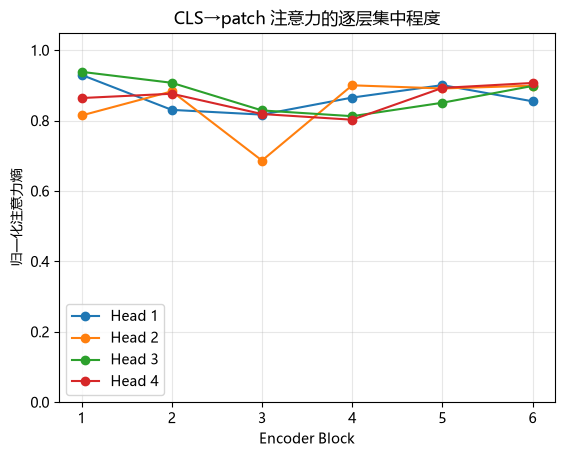

各层平均熵： [0.8865000009536743, 0.8741000294685364, 0.7875000238418579, 0.8450000286102295, 0.8837000131607056, 0.8895999789237976]


In [7]:
cls_patch_attention = attention[:, :, :, 0, 1:]
probabilities = cls_patch_attention / cls_patch_attention.sum(dim=-1, keepdim=True)
normalized_entropy = -(probabilities * probabilities.clamp_min(1e-12).log()).sum(dim=-1)
normalized_entropy = normalized_entropy / torch.log(torch.tensor(64.0, device=device))
mean_entropy = normalized_entropy.mean(dim=0).cpu()  # L x H

for head_index in range(mean_entropy.shape[1]):
    plt.plot(
        range(1, 7), mean_entropy[:, head_index], marker="o", label=f"Head {head_index + 1}"
    )
plt.ylim(0, 1.05)
plt.xticks(range(1, 7))
plt.xlabel("Encoder Block")
plt.ylabel("归一化注意力熵")
plt.title("CLS→patch 注意力的逐层集中程度")
plt.grid(alpha=0.3)
plt.legend()
fig = plt.gcf()
display(fig)
plt.close(fig)

print("各层平均熵：", mean_entropy.mean(dim=1).numpy().round(4).tolist())

## 9. Attention Map 能说明什么，不能说明什么

### 可以说明

- 在某一层、某个 head 中，CLS query 把较大权重分给了哪些 patch；
- 不同层、不同 head 的注意力分布是否存在差异；
- 模型的信息聚合模式是否呈现出可观察的空间结构。

### 不能直接说明

- 高注意力区域一定是预测的原因；
- 没有高亮的区域完全不影响结果；
- 最后一层单独代表完整模型的全部推理过程。

原因是模型还有残差连接、MLP、多层传播和分类头。Raw Attention 是一种观察窗口，不是严格的因果解释。更完整的跨层方法包括 Attention Rollout，解释预测还可以结合梯度方法或遮挡实验。

### 一套推荐的读图顺序

1. 先看真实标签、预测标签和置信度，区分正确样本与误分类样本；
2. 先看多头平均热力图，判断整体关注区域；
3. 再看各个 head，观察它们是互补、重复，还是有 head 依赖背景；
4. 沿层数比较热力图，关注信息是否逐渐聚合或扩散；
5. 最后看熵曲线，把“看起来集中”转化为可比较的数值；
6. 对可疑区域做遮挡或裁剪实验：遮住亮区后准确率明显下降，才更支持该区域对预测有实际贡献。

记住：热力图回答“注意力分配到哪里”，熵回答“分配得集中还是分散”，而遮挡实验更接近回答“这个区域是否真的影响预测”。

## 10. 本课总结

1. 当前每层注意力权重 shape 为 `B x 4 x 65 x 65`；
2. `attention[:, :, 0, 1:]` 表示 CLS query 对 64 个 patch keys 的注意力；
3. 64 个权重可以还原为 `8 x 8` 网格，再放大到原图尺寸；
4. 不同层和不同 head 可能形成不同的空间关注模式；
5. 注意力熵描述权重分散程度，但不能评价预测一定好坏；
6. Attention Map 应被视为观察工具，不能直接等同于因果解释。

下一步可以继续实现 **Attention Rollout**：把 6 层注意力和残差路径组合起来，观察 CLS 信息如何跨层累计传播。

## 11. 自测问题

1. 注意力矩阵最后两个 65 分别表示什么？
2. 为什么取 CLS 对 patch 的注意力时使用 `[0, 1:]`？
3. `average_attn_weights=False` 有什么作用？
4. 为什么 64 个权重可以 reshape 为 `8 x 8`？
5. 第一层和最后一层 Attention Map 的含义有什么区别？
6. 注意力熵越低代表什么？它是否一定更好？
7. 为什么不能把 Attention Map 直接称为模型的因果解释？